<a href="https://colab.research.google.com/github/VanChung-Nguyen/Adaptive-finite-time-ESO-based-LMPC-for-5DOF-Tower-Crane/blob/main/AI_UKF_3DDrone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.integrate import odeint
import scipy.optimize

import sympy as sp

import pandas as pd
import os
import copy

In [2]:
try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 4.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/usr/local/lib/python3.12/dist-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


  Cloning https://github.com/vanbreugel-lab/pybounds to /tmp/pip-req-build-206od2s8
  Running command git clone --filter=blob:none --quiet https://github.com/vanbreugel-lab/pybounds /tmp/pip-req-build-206od2s8
  Resolved https://github.com/vanbreugel-lab/pybounds to commit b847eb839f75308ed8ba402f0e3356f6148d465e
  Preparing metadata (setup.py) ... done
  Created wheel for pybounds: filename=pybounds-0.0.13-py3-none-any.whl size=19568 sha256=e057d2972d590947e8ad3a4f27a835010482b4424db12396ed64295d3c83ab60
  Stored in directory: /tmp/pip-ephem-wheel-cache-4ztcotlt/wheels/cb/f8/fb/ff1887f9a2f35c3edad7b1acb7da69437c1fd8d885a800578d
Successfully built pybounds


In [3]:
import tensorflow as tf

In [4]:
import sys
import requests
import importlib
import importlib.util
from pathlib import Path

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # 1) Try local import
    try:
        if directory is not None:
            directory = str(Path(directory).resolve())
            if directory not in sys.path:
                sys.path.insert(0, directory)
        module = importlib.import_module(package_name)
        return getattr(module, function_name) if function_name else module
    except ModuleNotFoundError:
        pass  # fall through to GitHub fetch
    except Exception as e:
        # If module exists but some other error occurred, surface it
        raise

    # 2) Fetch from GitHub (RAW)
    if giturl is None:
        giturl = (
            "https://raw.githubusercontent.com/"
            "VanChung-Nguyen/Nonlinear-and-Data-Driven-Estimation-3D-Drone/"
            f"main/Utility/{package_name}.py"
        )

    try:
        headers = {"User-Agent": "import_local_or_github/1.0"}
        r = requests.get(giturl, headers=headers, timeout=15)
        r.raise_for_status()
    except requests.RequestException as e:
        raise RuntimeError(f"Failed to fetch module from GitHub URL:\n{giturl}\nError: {e}")

    # Save to CWD as {package_name}.py so Python can import it
    target_path = Path.cwd() / f"{package_name}.py"
    target_path.write_text(r.text, encoding=r.encoding or "utf-8")

    # Make sure Python sees the new file
    importlib.invalidate_caches()

    # 3) Import the freshly written module
    module = importlib.import_module(package_name)
    return getattr(module, function_name) if function_name else module


# Usage
drone = import_local_or_github('drone', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', function_name='plot_tme', directory='../Utility')
generate_training_data_utility = import_local_or_github('generate_training_data_utility', directory='../Utility')
keras_ann_utility = import_local_or_github('keras_ann_utility', directory='../Utility')
keras_advanced_utility = import_local_or_github('keras_advanced_utility', directory='../Utility')
unscented_kalman_filter = import_local_or_github('unscented_kalman_filter', directory='../Utility')

In [5]:
f = drone.F().f
#3 type of measurement: h_all, h_opticalimu (h_opticalimu : the optical flow with measurement z), h_gpsimu
h = drone.H('h_opticalimu').h
hann = drone.H('h_ann').h

In [33]:
#types of trajectoru: 'hovering','circle','lemniscate','squiggle','random','circlezerovel','lemniscatezerovel','squigglezerovel','randomzerovel', 'fulltrajectory'
t_sim, x_sim, u_sim, y_sim, simulator = drone.simulate_drone(f, h=h, dt=0.1, tsim_length= 50,trajectory_shape='randomzerovel', rterm=1e-10)

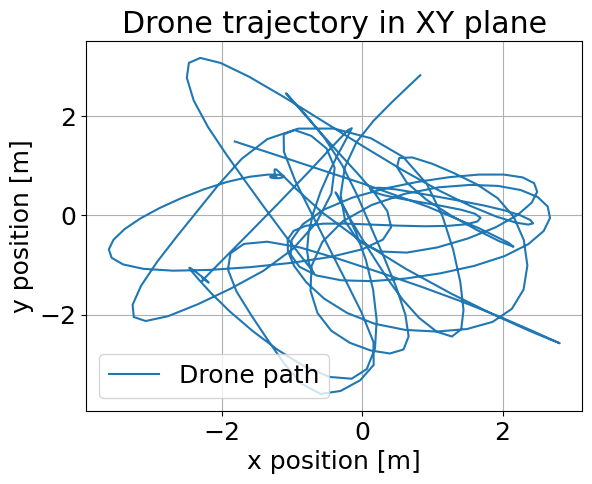

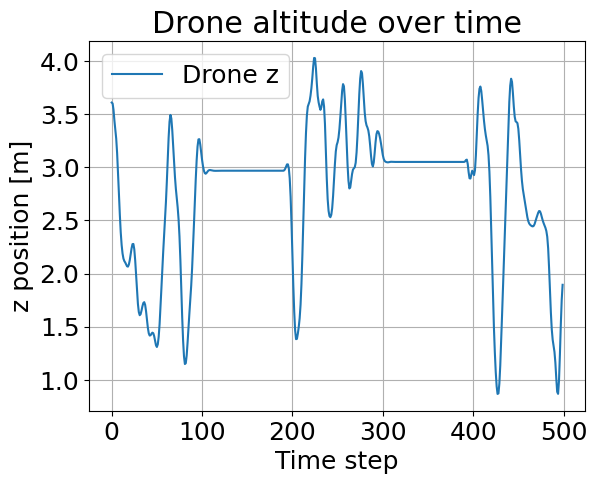

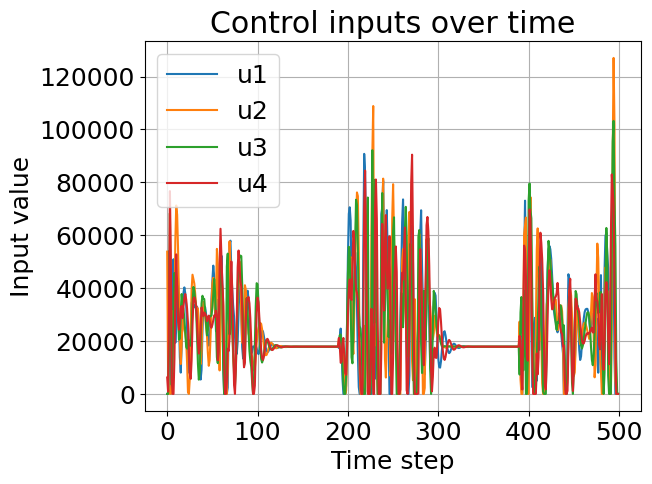

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_sim['x'], x_sim['y'], label='Drone path')
ax.set_xlabel('x position [m]')
ax.set_ylabel('y position [m]')
ax.set_title('Drone trajectory in XY plane')
ax.legend()
ax.grid(True)
plt.show()

# === 2. Plot Z (altitude) over time ===
fig1 = plt.figure()
ax1 = fig1.add_subplot(111)
ax1.plot(x_sim['z'], label='Drone z')
ax1.set_xlabel('Time step')
ax1.set_ylabel('z position [m]')
ax1.set_title('Drone altitude over time')
ax1.legend()
ax1.grid(True)
plt.show()

# === 3. Plot control inputs (u_sim) ===
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)

# Loop through each control input
for key in u_sim.keys():
    ax2.plot(u_sim[key], label=key)

ax2.set_xlabel('Time step')
ax2.set_ylabel('Input value')
ax2.set_title('Control inputs over time')
ax2.legend()
ax2.grid(True)
plt.show()

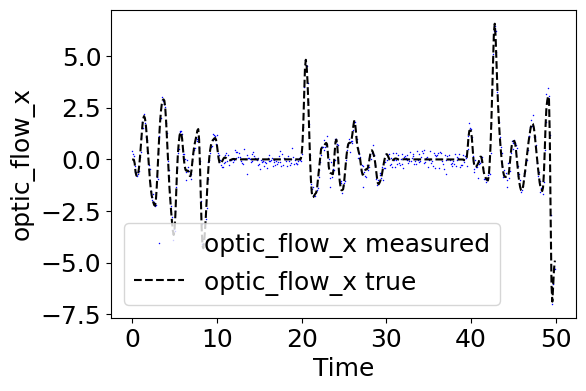

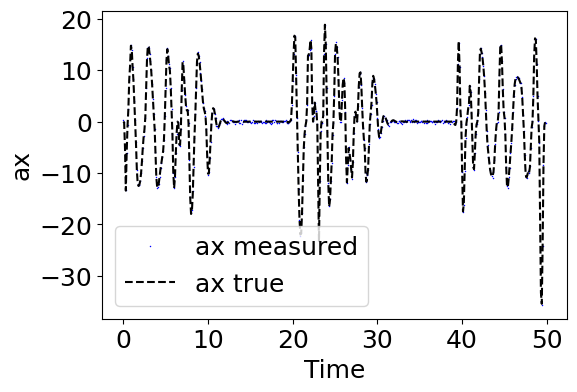

In [35]:
measurement_noise_stds = {'optic_flow_x': 0.25,
                          'optic_flow_y': 0.25,
                          'phi': 0.1,
                          'theta': 0.1,
                          'psi': 0.1,
                          'phidot': 0.1,
                          'thetadot': 0.1,
                          'psidot': 0.1,
                          'ax': 0.2,
                          'ay': 0.2,
                          'az': 0.2
                         }
y_noisy = {key: y_sim[key] + np.random.normal(0, measurement_noise_stds[key], len(y_sim[key])) for key in y_sim.keys()}
plot_tme(t_sim, y_sim['optic_flow_x'], y_noisy['optic_flow_x'], label_var='optic_flow_x')
plot_tme(t_sim, y_sim['ax'], y_noisy['ax'], label_var='ax')
y_noisy_df = pd.DataFrame(y_noisy)
u_sim_df = pd.DataFrame(u_sim)
x_sim_df = pd.DataFrame(x_sim)

In [36]:
model_kerasx = 'xdot_estimator_network_trained.keras'
model_kerasy = 'ydot_estimator_network_trained.keras'
model_kerasz = 'altitude_estimator_network_trained.keras'

for path in [model_kerasx,model_kerasy,model_kerasz]:
    if not os.path.exists(path):
        giturl = 'https://raw.githubusercontent.com/VanChung-Nguyen/Nonlinear-and-Data-Driven-Estimation-3D-Drone/main/'
        generate_training_data_utility.download_data(path, giturl=giturl, unzip=False)


In [37]:
from tensorflow import keras

model_pathx = 'xdot_estimator_network_trained.keras'
modelx = keras.models.load_model(model_pathx)
modelx.summary()

model_pathy = 'ydot_estimator_network_trained.keras'
modely = keras.models.load_model(model_pathy)
modely.summary()

model_pathz = 'altitude_estimator_network_trained.keras'
modelz = keras.models.load_model(model_pathz)
modelz.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │         1,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,425 (60.26 KB)

 Trainable params: 5,141 (20.08 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │         4,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,925 (89.55 KB)

 Trainable params: 7,641 (29.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,284 (59.71 KB)

In [38]:
# almost direct from Claude
def create_fast_inference_model(trained_model):
    """
    Create an optimized version of the model for fast inference using XLA compilation.
    Removes training-specific components (dropout, regularization).

    Note: The first prediction will be slower as it includes compilation time.
    Subsequent predictions will be fast.

    Parameters:
    -----------
    trained_model : keras model
        The trained model

    Returns:
    --------
    inference_func : tf.function
        Optimized inference function for predictions

    Example:
    --------
    >>> fast_predict = create_fast_inference_model(model)
    >>> # First call is slow (compilation)
    >>> predictions = fast_predict(X_core_batch, X_aux_batch) # X_aux_batch is optional, depending on model
    >>> # Subsequent calls are fast
    >>> predictions = fast_predict(X_core_batch2, X_aux_batch2) # X_aux_batch is optional, depending on model
    """
    # Get the base functional model (without custom training logic)
    inputs = trained_model.inputs
    outputs = trained_model.outputs

    # Create inference-only model
    inference_model = keras.Model(inputs=inputs, outputs=outputs)

    # Get only trainable weights (excludes metric trackers)
    trainable_weights = trained_model.trainable_weights
    inference_trainable_weights = inference_model.trainable_weights

    # Copy weights
    for target_weight, source_weight in zip(inference_trainable_weights, trainable_weights):
        target_weight.assign(source_weight)

    # Create optimized prediction function
    @tf.function(jit_compile=True)  # XLA compilation for speed
    def fast_predict(x_core, x_aux=None):
        if x_aux is None:
            return inference_model([x_core], training=False)
        else:
            return inference_model([x_core, x_aux], training=False)

    print("✓ Fast inference model created with XLA compilation")
    print("  First prediction will be slow (includes compilation)")
    print("  Subsequent predictions will be fast")
    print("  Use: predictions = fast_predict(X_core_tensor)")
    print("  --- OR ---")
    print("  Use: predictions = fast_predict(X_core_tensor, X_aux_tensor)")
    print("  Note: Inputs must be TensorFlow tensors (use tf.constant())")

    return fast_predict

In [39]:
fast_predictx = create_fast_inference_model(modelx)
fast_predicty = create_fast_inference_model(modely)
fast_predictz = create_fast_inference_model(modelz)

✓ Fast inference model created with XLA compilation
  First prediction will be slow (includes compilation)
  Subsequent predictions will be fast
  Use: predictions = fast_predict(X_core_tensor)
  --- OR ---
  Use: predictions = fast_predict(X_core_tensor, X_aux_tensor)
  Note: Inputs must be TensorFlow tensors (use tf.constant())
✓ Fast inference model created with XLA compilation
  First prediction will be slow (includes compilation)
  Subsequent predictions will be fast
  Use: predictions = fast_predict(X_core_tensor)
  --- OR ---
  Use: predictions = fast_predict(X_core_tensor, X_aux_tensor)
  Note: Inputs must be TensorFlow tensors (use tf.constant())
✓ Fast inference model created with XLA compilation
  First prediction will be slow (includes compilation)
  Subsequent predictions will be fast
  Use: predictions = fast_predict(X_core_tensor)
  --- OR ---
  Use: predictions = fast_predict(X_core_tensor, X_aux_tensor)
  Note: Inputs must be TensorFlow tensors (use tf.constant())


In [40]:
time_window = 10
input_namesx =  ['optic_flow_x', 'ax', 'az']
input_namesy =  ['optic_flow_y', 'ay', 'az']
input_namesz =  ['optic_flow_x', 'optic_flow_y', 'phi', 'theta', 'psi', 'ax', 'ay', 'az']
input_offsets = np.arange(time_window)*-1
y_noisy_dfx_aug = keras_ann_utility.collect_offset_rows(y_noisy_df,
                                       states=input_namesx,
                                       controls=None,
                                       outputs=None,
                                       state_offsets=input_offsets,
                                       control_offsets=None,
                                       output_offsets=None)
y_noisy_dfy_aug = keras_ann_utility.collect_offset_rows(y_noisy_df,
                                       states=input_namesy,
                                       controls=None,
                                       outputs=None,
                                       state_offsets=input_offsets,
                                       control_offsets=None,
                                       output_offsets=None)
y_noisy_dfz_aug = keras_ann_utility.collect_offset_rows(y_noisy_df,
                                       states=input_namesz,
                                       controls=None,
                                       outputs=None,
                                       state_offsets=input_offsets,
                                       control_offsets=None,
                                       output_offsets=None)


In [41]:
xdot_pred = []
for i in range(len(y_noisy_dfx_aug)):
    y = y_noisy_dfx_aug.values[i,:]
    y_tf = tf.constant(np.atleast_2d(y))
    xdot_pred.append( fast_predictx(y_tf) )
xdot_pred = np.ravel(tf.stack(xdot_pred).numpy())
ydot_pred = []
for i in range(len(y_noisy_dfy_aug)):
    y = y_noisy_dfy_aug.values[i,:]
    y_tf = tf.constant(np.atleast_2d(y))
    ydot_pred.append( fast_predicty(y_tf) )
ydot_pred = np.ravel(tf.stack(ydot_pred).numpy())
z_pred = []
for i in range(len(y_noisy_dfz_aug)):
    y = y_noisy_dfz_aug.values[i,:]
    y_tf = tf.constant(np.atleast_2d(y))
    z_pred.append( fast_predictz(y_tf) )
z_pred = np.ravel(tf.stack(z_pred).numpy())

In [42]:
x_accel_col_names = []
for col_name in y_noisy_dfx_aug.keys():
  if 'ax' in col_name:
    x_accel_col_names.append(col_name)

y_accel_col_names = []
for col_name in y_noisy_dfy_aug.keys():
  if 'ay' in col_name:
    y_accel_col_names.append(col_name)

z_accel_col_names = []
for col_name in y_noisy_dfz_aug.columns:
    if 'ax' in col_name or 'ay' in col_name:
        z_accel_col_names.append(col_name)

In [43]:
min_accelsx = np.abs(y_noisy_dfx_aug[x_accel_col_names]).min(axis=1)
min_accelsy = np.abs(y_noisy_dfy_aug[y_accel_col_names]).min(axis=1)
min_accelsz = np.abs(y_noisy_dfz_aug[z_accel_col_names]).min(axis=1)

In [44]:
R_aug_xdot = 1/min_accelsx
R_aug_ydot = 1/min_accelsy
R_aug_z = 1/min_accelsz

In [45]:
xdot_pred_padded = np.hstack(([0]*(time_window-1), xdot_pred))
R_aug_xdot_padded = np.hstack(([1e8]*(time_window-1), R_aug_xdot))
ydot_pred_padded = np.hstack(([0]*(time_window-1), ydot_pred))
R_aug_ydot_padded = np.hstack(([1e8]*(time_window-1), R_aug_ydot))
z_pred_padded = np.hstack(([0]*(time_window-1), z_pred))
R_aug_z_padded = np.hstack(([1e8]*(time_window-1), R_aug_z))

In [46]:
# Add the augmented measurements to the augmented measurement dataframe
y_noisy_df_aug = copy.copy(y_noisy_df)
y_noisy_df_aug['xdot_pred'] = xdot_pred_padded
y_noisy_df_aug['ydot_pred'] = ydot_pred_padded
y_noisy_df_aug['z_pred'] = z_pred_padded

In [47]:
R = np.diag( list(measurement_noise_stds.values()) )**2
R_list = []
for i in range(y_noisy_df_aug.shape[0]):
    R_aug = np.eye(y_noisy_df_aug.shape[1])
    R_aug[0:y_noisy_df.shape[1], 0:y_noisy_df.shape[1]] = R
    R_aug[-3, -3] = R_aug_xdot_padded[i]
    R_aug[-2, -2] = R_aug_ydot_padded[i]
    R_aug[-1, -1] = R_aug_z_padded[i]
    R_list.append(R_aug)

In [48]:
R_list_arr = np.dstack(R_list)

In [49]:
def h_aug(x_vec, u_vec):
  x, y, z, phi, theta, psi, xdot, ydot, zdot, phidot, thetadot, psidot = x_vec
  y = h(x_vec, u_vec)
  y_aug = np.hstack((y, z, ydot, zdot))
  return y_aug

In [50]:
x0 = np.array([10.0, 10.0, 5.5, 0.5, 0.5, 0.5, 50.0, 50.0, 20.0, 5.5, 5.5, 5.5])
u0 = np.array([17854.2, 17854.2, 17854.2, 17854.2])

P0 = np.eye(12)*0.1
Q = np.diag([1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3])
dt = np.mean(np.diff(t_sim))

In [51]:
UKF = unscented_kalman_filter.UKF(f, h_aug, x0, u0, P0, Q, R_aug, dynamics_type='continuous', discretization_timestep=dt,alpha=0.25)

In [52]:
UKF.estimate(y_noisy_df_aug, u_sim_df, R=R_list_arr)

In [53]:
UKF.history.keys()
# State estimate
x_est = pd.DataFrame(np.vstack(UKF.history['X']), columns=f(None,None,return_state_names=True))
# Covariance diagonals
P_diags = np.vstack([np.diag(UKF.history['P'][i]) for i in range(len(UKF.history['P']))])
P_diags = pd.DataFrame(P_diags, columns=f(None,None,return_state_names=True))

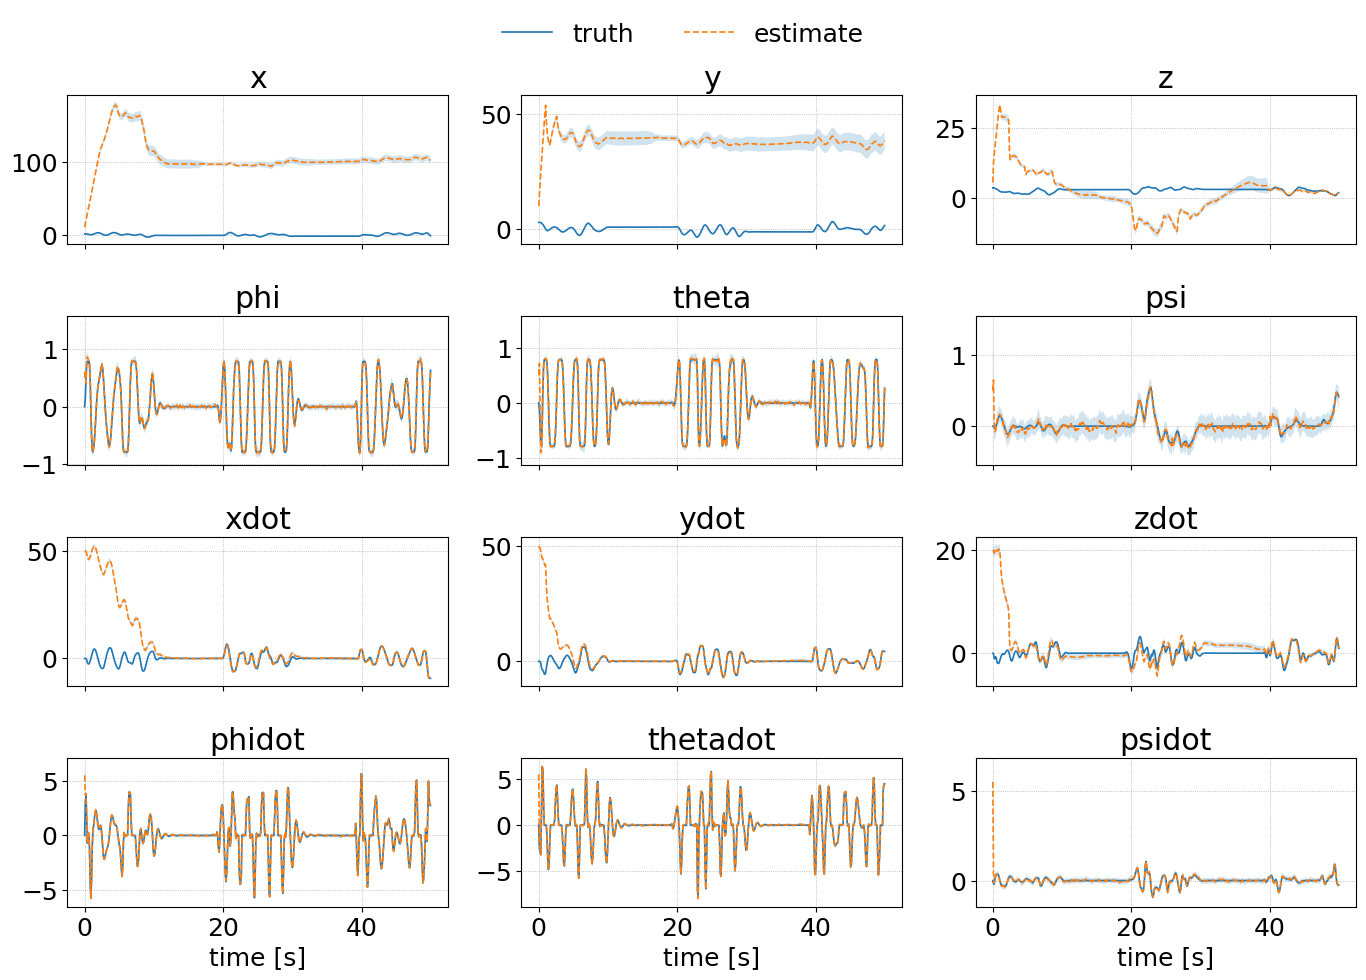

In [54]:
STATE_ORDER = [
    "x","y","z","phi","theta","psi",
    "xdot","ydot","zdot","phidot","thetadot","psidot"
]
name_to_idx = {n:i for i,n in enumerate(STATE_ORDER)}
N_STATES = len(STATE_ORDER)

def _as_series(container, name):
    """
    Return 1D array for a state:
      - dict-like: container[name] -> (T,)
      - array (T, N_STATES) or (N_STATES, T)
      - array (T,) falls back to ravel
    """
    if isinstance(container, dict):
        return np.asarray(container[name]).ravel()

    arr = np.asarray(container)
    i = name_to_idx[name]

    if arr.ndim == 2:
        # prefer (T, N) if matches N_STATES
        if arr.shape[1] == N_STATES:
            return arr[:, i].ravel()
        # or (N, T)
        if arr.shape[0] == N_STATES:
            return arr[i, :].ravel()

    return arr.ravel()

def _as_variance(P_diags, name):
    """
    Return variance (T,) for the given state.
      - dict-like: P_diags[name] -> (T,)
      - array (T, N_STATES) or (N_STATES, T)
      - array (T,) falls back to ravel
    """
    if isinstance(P_diags, dict):
        return np.asarray(P_diags[name]).ravel()

    arr = np.asarray(P_diags)
    i = name_to_idx[name]

    if arr.ndim == 2:
        if arr.shape[1] == N_STATES:
            return arr[:, i].ravel()
        if arr.shape[0] == N_STATES:
            return arr[i, :].ravel()

    return arr.ravel()

def _align_common_lengths(*arrays):
    """
    Trim all arrays to the same min length along their first dimension.
    Ignores None; returns trimmed copies.
    """
    valid = [a for a in arrays if a is not None]
    L = min(len(np.asarray(a)) for a in valid)
    out = []
    for a in arrays:
        if a is None:
            out.append(None)
        else:
            a = np.asarray(a)
            out.append(a[:L].copy())
    return out

def plot_state_with_ci(ax, t, x_true, x_est, var, label):
    ax.plot(t, x_true, lw=1.2, label="truth")
    ax.plot(t, x_est,  lw=1.2, linestyle="--", label="estimate")
    sigma = np.sqrt(np.maximum(var, 0.0))
    ax.fill_between(t, x_est + 3*sigma, x_est - 3*sigma, alpha=0.2)
    ax.set_title(label)
    ax.grid(True, linestyle=":", linewidth=0.6)

# ------------ main plotting ------------
# Assumes you already have: t_sim, x_sim, x_est, P_diags
# x_sim/x_est can be dicts keyed by state names, or arrays; P_diags as above.

t_sim = np.asarray(t_sim).ravel()

fig, axes = plt.subplots(4, 3, figsize=(14, 10), sharex=True)
axes = axes.ravel()

for k, state in enumerate(STATE_ORDER):
    ax = axes[k]

    # extract raw series
    x_true_raw = _as_series(x_sim, state)
    x_hat_raw  = _as_series(x_est, state)
    var_raw    = _as_variance(P_diags, state)

    # align ALL four: time, truth, estimate, variance
    t_al, x_true, x_hat, var = _align_common_lengths(t_sim, x_true_raw, x_hat_raw, var_raw)

    plot_state_with_ci(ax, t_al, x_true, x_hat, var, state)

# Legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

for ax in axes[-3:]:
    ax.set_xlabel("time [s]")

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
